# Full Workflow

This is the complete workflow.

## Import Libraries

In [1]:
import torch
import numpy as np
import pennylane as qml
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from PIL import Image
from itertools import product
from collections import Counter
from pennylane import numpy as pnp
from pennylane.templates import QFT
from skimage.transform import resize
from torch.nn.functional import relu
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from pennylane.templates import StronglyEntanglingLayers

/Users/aleksandrak/Desktop/thesis_experiments/.venv/lib/python3.12/site-packages/pennylane/__init__.py:212: PennyLaneDeprecationWarning: PennyLane v0.44 has dropped maintainence support for NumPy < 2.0.0. You have version 1.26.4 installed. Future versions of PennyLane will not work with NumPy<2.0. Please consider upgrading NumPy using `python -m pip install numpy --upgrade`. 
  warnings.warn(


## Load Data

In [2]:
# loading mnist from keras.datasets
from keras.datasets import mnist
(X_train_full, y_train_full), (X_test_full, y_test_full) = mnist.load_data()
X = pnp.concatenate((X_train_full, X_test_full), axis=0)
y = pnp.concatenate((y_train_full, y_test_full), axis=0)

X = X.astype(pnp.uint8) # better to convert for binerization
y = y.astype(pnp.uint8)

2026-03-20 00:36:32.716577: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
X.shape, y.shape

((70000, 28, 28), (70000,))

## Data Preparation

In [4]:
# focus on binary classification
mask = (y == 4) | (y == 9)

X, y = X[mask], y[mask]

In [5]:
n_samples = 300

X = X.values if hasattr(X, "values") else X # safer conversion

X = X[:n_samples]
y = y[:n_samples]

In [6]:
print("Unique labels before encoding:", pnp.unique(y))
y = pnp.where(y == 4, -1, 1)
print("Unique labels after encoding:", pnp.unique(y))

Unique labels before encoding: [4 9]
Unique labels after encoding: [-1  1]


In [7]:
X = X / 255.0
X = X.reshape(-1, 28, 28)

print(X.shape)
print("Pixel range:", X.min(), X.max())

(300, 28, 28)
Pixel range: 0.0 1.0


In [8]:
# convert each 28x28 binarised image to 8x8, then flatten to length 64
def to_8x8_vector(img_row):
    img_8x8 = resize(
        img_row,
        (8, 8),
        anti_aliasing=True,
        preserve_range=True,
        order=1 # controlling interpolation
    )
    img_8x8 = img_8x8.flatten().astype(float)
    # img_8x8 -= img_8x8.mean()
    norm = pnp.linalg.norm(img_8x8)
    if norm > 0:
        img_8x8 /= norm
    else:
        img_8x8[0] = 1.0
      # should be shape (64,)
    return img_8x8

# apply transformation to all images
X_8x8 = pnp.array([to_8x8_vector(x) for x in X], dtype=float)
X_8x8.shape

(300, 64)

###  QJPEG Compression

In [9]:
def qjpeg_feature_extractor(img, n0, n2, shots):
    """
    Input: single image (28x28)
    Output: feature vector of size (2**n2,)
    """

    Cr, Cc = img.shape

    # --- vectorization ---
    states, norm = vectorization(img, Cr, Cc)

    # --- build circuit ---
    qcs = circuit_builder(states, n0, n2, shots)

    # --- run circuits ---
    out_freq = reconstruction(qcs, n2, norm)  # (num_patches, 2**n2)

    # --- compress patches (IMPORTANT) ---
    features = out_freq.mean(axis=0)  # (2**n2,)
    features = features / pnp.linalg.norm(features)

    # --- convert to tensor ---
    x = torch.tensor(features, dtype=torch.float32)

    # --- probabilities → amplitudes ---
    x = torch.sqrt(x + 1e-8)

    # --- normalize for amplitude embedding ---
    x = x / (torch.norm(x) + 1e-8)

    return x

from skimage.transform import resize

def preprocess_for_qjpeg(img):
    img_resized = resize(
        img,
        (16, 16),
        anti_aliasing=True,
        preserve_range=True
    )
    return img_resized

def vectorization(img, Cr, Cc, renorm=False):
    "Vectorize the image into amplitude-encoding patches suitable for quantum circuits"
    # split the original image (Mr, Mc) into S equal-size patches of shape (Cr, Cc)
    Mr, Mc = img.shape
    patches = (img.reshape(Mc//Cr, Cr, -1, Cc).swapaxes(1, 2).reshape(-1, Cr, Cc))
    # 64 patches, (64, 64, 64) shape; S=64

    # vectorize each patch and collect all in a (N, Cr*Cc) array
    vect_patches = pnp.reshape(patches, (patches.shape[0], Cr * Cc)) # (64, 4096)

    # normalize each (Cr*Cc) vector to the intensity of the corresponding (Cr, Cc) patch
    states = pnp.zeros((patches.shape[0], Cr * Cc)) # (64, 4096)
    norm = pnp.zeros(patches.shape[0])

    for idx in range(patches.shape[0]): # for each patch
        # compute the sum of pixels intensities
        norm[idx] = vect_patches[idx].sum()
        if norm[idx] == 0:
            raise ValueError('Pixel value is 0')
        # normalize the patch vector so that its entries sum is 1
        tmp = vect_patches[idx] / norm[idx]
        # take the element-wise square root of the normalized vector
        states[idx] = pnp.sqrt(tmp)
    if renorm == False:
        norm = pnp.ones(patches.shape[0])
    print(states[:10])

    return states, norm # amplitudes, pixek intensities' sums

def qft_swaps(wires):
    n = len(wires)
    # apply QFT to all qubits
    qml.QFT(wires=wires)
    # add swaps to reverse qubit order!
    for i in range(n // 2):
        qml.SWAP(wires=[wires[i], wires[n - i - 1]])


def iqft_swaps(wires):
    n = len(wires)
    # swaps again - BEFORE iqft
    for i in reversed(range(n // 2)):
        qml.SWAP(wires=[wires[i], wires[n-i-1]])
    qml.adjoint(QFT)(wires=wires)

def circuit_builder(states, n0, n2, shots):
    ntilde = (n0 - n2) // 2
    n1 = n0 - ntilde

    qnodes = []

    for idx in range(states.shape[0]):
        # qnode to capture current input state
        @qml.qnode(dev)
        def circuit():
            print("State norm:", pnp.linalg.norm(states[idx]))
            # initializing the state (using AmplitudeEmbedding here, but I'm wondering if something else could work faster)
            qml.AmplitudeEmbedding(states[idx], wires=range(n0))

            # Hadamard on all n0 qubits
            for w in range(n0):
                qml.Hadamard(wires=w)

            # apply QFT on all qubits
            qft_swaps(wires=range(n0))

            # apply IQFT on first n1 qubits
            iqft_swaps(wires=range(n1))

            # setting boundaries - Rule 2
            discard_start = n0 // 2 - ntilde
            discard_end = n0 // 2 - 1
            discarded_qubits = set(range(discard_start, discard_end + 1))

            measured_qubits = [q for q in range(n1) if q not in discarded_qubits]

            # Hadamard on remaining qubits
            for q in measured_qubits:
                qml.Hadamard(wires=q)

            print(f'Measured qubits: {measured_qubits}')

            return qml.probs(wires=measured_qubits)
        qnodes.append(circuit)

    return qnodes


def reconstruction(qnodes, n2, norm):
    out_freq = pnp.zeros((len(qnodes), 2 ** n2))
    for idx, qnode in enumerate(qnodes):
        probs = qnode()  # already a vector of length 2**n2
        print(f"Circuit {idx} probs:", probs)
        out_freq[idx, :] = probs * norm[idx]
    return out_freq

def devectorization(out_freq):
    S = out_freq.shape[0]
    nrow = int(pnp.sqrt(out_freq.shape[1])) # rows per patch
    ncol = nrow

    decoded_patches = pnp.reshape(out_freq, \
                                  (out_freq.shape[0], nrow, ncol)) # (S, nrow, ncol)

    im_h, im_w = nrow * int(pnp.sqrt(S)), ncol * int(pnp.sqrt(S)) # final shape

    # initialization
    decoded_img = pnp.zeros((im_w, im_h))

    idx = 0
    for row in pnp.arange(im_h - nrow + 1, step=nrow):
        for col in pnp.arange(im_w - ncol + 1, step=ncol):
            decoded_img[row:row+nrow, col:col+ncol] = decoded_patches[idx]
            idx += 1

    return decoded_img

### Train/test Split

In [10]:
idx = pnp.arange(n_samples)

idx_train, idx_test, y_train, y_test = train_test_split(
    idx, y, test_size=0.2, random_state=42, stratify=y, shuffle=True
)

In [11]:
n0 = 8  # since 16x16 = 256 = 2^8
n2 = 6  # output dimension = 64 → matches kernel
shots = 256

# define device with n0 qubits
dev = qml.device("default.qubit", wires=n0, shots=shots)
X_train_qjpeg = []
X_test_qjpeg = []

print("Extracting QJPEG features (train)...")
for i in range(len(idx_train)):
    img = preprocess_for_qjpeg(X[idx_train[i]])
    feat = qjpeg_feature_extractor(img, n0=n0, n2=n2, shots=shots)
    X_train_qjpeg.append(feat)

print("Extracting QJPEG features (test)...")
for i in range(len(idx_test)):
    img = preprocess_for_qjpeg(X[idx_test[i]])
    feat = qjpeg_feature_extractor(img, n0=n0, n2=n2, shots=shots)
    X_test_qjpeg.append(feat)

X_train_qjpeg = torch.stack(X_train_qjpeg).float()
X_test_qjpeg  = torch.stack(X_test_qjpeg).float()

Extracting QJPEG features (train)...
[[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 4.90390006e-09 2.68791719e-06 5.89313008e-05
  1.14075481e-04 1.25207266e-04 3.89735892e-05 4.93445425e-08
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  1.99843060e-08 4.79152062e-04 8.49410866e-03 6.54081145e-02
  1.21613994e-01 1.33000646e-01 4.23423425e-02 8.16663379e-04
  9.26750002e-09 0.00000000e+00 0

/Users/aleksandrak/Desktop/thesis_experiments/.venv/lib/python3.12/site-packages/pennylane/devices/device_api.py:201: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


Circuit 0 probs: [0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.00390625
 0.01953125 0.00390625 0.         0.         0.0078125  0.00390625
 0.         0.1171875  0.09765625 0.05078125 0.         0.
 0.0078125  0.         0.0546875  0.03515625 0.01953125 0.0625
 0.         0.         0.         0.         0.015625   0.125
 0.1328125  0.03515625 0.00390625 0.         0.         0.
 0.         0.0078125  0.08203125 0.         0.         0.
 0.         0.         0.         0.         0.09375    0.
 0.         0.         0.         0.         0.         0.
 0.01953125 0.         0.         0.        ]
[[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+

In [12]:
# sanity check, make sure no NaNs exist and all vectors are normalised, i.e. norm is around 1
print("Any NaNs?", pnp.isnan(X_8x8).any())
print("Norm check:", pnp.min(pnp.linalg.norm(X_8x8, axis=1)), pnp.max(pnp.linalg.norm(X_8x8, axis=1)))

Any NaNs? False
Norm check: 0.9999999999999998 1.0000000000000002


In [13]:
X_train = X_8x8[idx_train]
X_test  = X_8x8[idx_test]

## QEK definition

In [14]:
n_qubits = 6
dev_ideal = qml.device('default.qubit', wires=n_qubits)

In [15]:
# -----------------------------
# Quantum circuit components
# -----------------------------
def qek_layer_amplitude(x, theta):
    # Data re-uploading via phase gates (breaks kernel symmetry)
    wires = range(n_qubits)

    qml.AmplitudeEmbedding(
        x,
        wires=range(n_qubits),
        normalize=False
    )
    for l in range(theta.shape[0]):
        for j, wire in enumerate(wires):
            qml.Hadamard(wires=wire)
            qml.RZ(x[i], wires=wire)
        for j, wire in enumerate(wires):
            # qml.RY(theta[l, j, 0], wires=wire)
            qml.CRZ(theta[l, j, 0], wires=[j, (j+1) % n_qubits])

        for j, wire in enumerate(wires):
            qml.RX(theta[l, j, 1], wires=wire)
            qml.RY(theta[l, j, 2], wires=wire)

    # qml.StronglyEntanglingLayers(theta, wires=wires)

# -----------------------------
# Quantum kernel QNode
# -----------------------------
@qml.qnode(dev_ideal, interface="torch", diff_method="backprop")
def qek_kernel(x1, x2, theta, n_qubits):
    """Adjoint-based kernel: |<phi(x1)|phi(x2)>|^2."""
    qek_layer_amplitude(x1, theta)
    qml.adjoint(qek_layer_amplitude)(x2, theta)
    return qml.expval(qml.Projector([0]*n_qubits, wires=range(n_qubits)))


def split_indices(N, block_size):
    """Return a list of index blocks for M-SPLIT."""
    blocks = []
    for start in range(0, N, block_size):
        end = min(start + block_size, N)
        blocks.append(pnp.arange(start, end))
    return blocks

def compute_block_kernel(X, theta, block_idx, n_qubits):
    """Compute PSD-corrected kernel block."""
    X_block = X[block_idx]
    n = len(block_idx)
    K_block = torch.zeros((n, n), dtype=X_block.dtype, device=X_block.device)

    for i in range(n):
        for j in range(i, n):
            val = qek_kernel(X_block[i], X_block[j], theta, n_qubits)
            K_block[i, j] = val.to(torch.float32)
            K_block[j, i] = val.to(torch.float32)

    # PSD projection
    K_block_np = K_block.detach().numpy()
    eigvals, eigvecs = pnp.linalg.eigh(K_block_np)
    eigvals[eigvals < 0] = 0
    K_block_psd = torch.tensor(eigvecs @ pnp.diag(eigvals) @ eigvecs.T, dtype=X_block.dtype)

    # Normalize diagonals to 1
    diag = torch.sqrt(torch.diag(K_block_psd))
    K_block_psd /= diag[:, None]
    K_block_psd /= diag[None, :]

    return K_block_psd

def kernel_matrix(X, theta):
    n = len(X)
    K = torch.zeros((n, n), dtype=torch.float32)

    for i in range(n):
        for j in range(i, n):
            val = qek_kernel(X[i], X[j], theta, 6)

            K[i, j] = val
            K[j, i] = val

    return K


def msplit_kernel(X, theta, n_qubits, block_size=10):
    N = len(X)
    blocks = split_indices(N, block_size)
    K = torch.zeros((N, N), dtype=torch.float32)

    # Compute each block independently
    for block in blocks:
        K_block = compute_block_kernel(X, theta, block, n_qubits)
        idx = pnp.ix_(block, block)
        K[idx] = K_block

    return K

# -----------------------------
# Minibatch kernel matrix
# -----------------------------
def kernel_matrix_minibatch(X_batch, theta, n_qubits):
    """Compute symmetric kernel matrix for a minibatch."""
    n = X_batch.shape[0]
    K = torch.zeros((n, n), dtype=X_batch.dtype)
    for i in range(n):
        for j in range(i, n):
            val = qek_kernel(X_batch[i], X_batch[j], theta, n_qubits)
            K[i, j] = val
            K[j, i] = val
    return K

# -----------------------------
# Hinge loss for SVM
# -----------------------------
def hinge_loss_kernel(K, y, alpha):
    """Squared hinge loss with dual variables alpha."""
    preds = K @ (alpha * y)
    return torch.mean(relu(1 - y * preds) ** 2)

def kernel_target_alignment(K, y, eps=1e-8):
    y = y.view(-1,1)
    K_star = y @ y.T

    num = torch.sum(K * K_star)
    den = torch.sqrt(torch.sum(K**2) + eps) * torch.sqrt(torch.sum(K_star**2) + eps)

    return num / den

def compute_block_kernel_train(X, theta, block_idx, n_qubits):
    """Differentiable kernel block (no PSD projection)."""

    X_block = X[block_idx]
    n = len(block_idx)

    # Collect values to avoid in-place operations
    kernel_values_rows = []
    for i in range(n):
        row_values = []
        for j in range(n):
            if j < i:
                # Leverage symmetry to avoid recomputing
                row_values.append(kernel_values_rows[j][i])
            else:
                val = qek_kernel(X_block[i], X_block[j], theta, n_qubits)
                row_values.append(val.to(torch.float32))
        kernel_values_rows.append(row_values)

    # Stack the collected tensor values to form K_block
    K_block = torch.stack([torch.stack(row) for row in kernel_values_rows])

    return K_block

def center_kernel(K):
    n = K.shape[0]
    one = torch.ones((n, n), dtype=K.dtype, device=K.device) / n
    return K - one @ K - K @ one + one @ K @ one


def msplit_kernel_train(X, theta, n_qubits, block_size=10):
    N = len(X)
    blocks = split_indices(N, block_size)
    K = torch.zeros((N, N), dtype=torch.float32) # K here does not need requires_grad=True if filled by gradient-tracking tensors

    # Compute each block independently
    for block in blocks:
        K_block = compute_block_kernel_train(X, theta, block, n_qubits) # Call the differentiable version
        idx = pnp.ix_(block, block)
        K[idx] = K_block

    return K


def quantum_kernel_train_kta(X_train, y_train, n_qubits,
                             n_layers=2, steps=150, batch_size=12,
                             lr=0.01, block_size=4, verbose=True,
                             max_grad_norm=1.0):  # <-- new parameter for clipping

    N = len(X_train)

    X_train = torch.as_tensor(X_train, dtype=torch.float32)
    y_train = torch.as_tensor(y_train, dtype=torch.float32)

    theta = torch.randn(n_layers, n_qubits, 3, requires_grad=True)
    optimizer = torch.optim.Adam([theta], lr=lr)
    kta_history = []

    for step in range(steps):

        optimizer.zero_grad()

        idx = pnp.random.choice(len(X_train), batch_size, replace=False)
        Xb = X_train[idx, :]  # explicitly keep 2D
        yb = y_train[idx]

        Kb = msplit_kernel_train(Xb, theta, n_qubits, block_size)

        # normalize kernel
        diag = torch.sqrt(torch.diag(Kb) + 1e-6)
        Kb = Kb / (diag[:, None] * diag[None, :] + 1e-6)

        Kc = center_kernel(Kb)
        alignment = kernel_target_alignment(Kc, yb)

        loss = - 5 * alignment
        loss.backward()

        # --- gradient clipping ---
        torch.nn.utils.clip_grad_norm_([theta], max_grad_norm)

        optimizer.step()

        kta_history.append(alignment.item())

        if verbose and step % 5 == 0:
            print(f"Step {step:03d} | KTA = {alignment.item():.4f}")

    return theta, kta_history

/Users/aleksandrak/Desktop/thesis_experiments/.venv/lib/python3.12/site-packages/pennylane/math/interface_utils.py:137: UserWarning: Contains tensors of types {'torch', 'autograd'}; dispatch will prioritize TensorFlow, PyTorch, and Jax over Autograd. Consider replacing Autograd with vanilla NumPy.
  warnings.warn(
/var/folders/by/pqh4gvw52t5fm7pvbqnvcyy00000gn/T/ipykernel_60529/2823860554.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


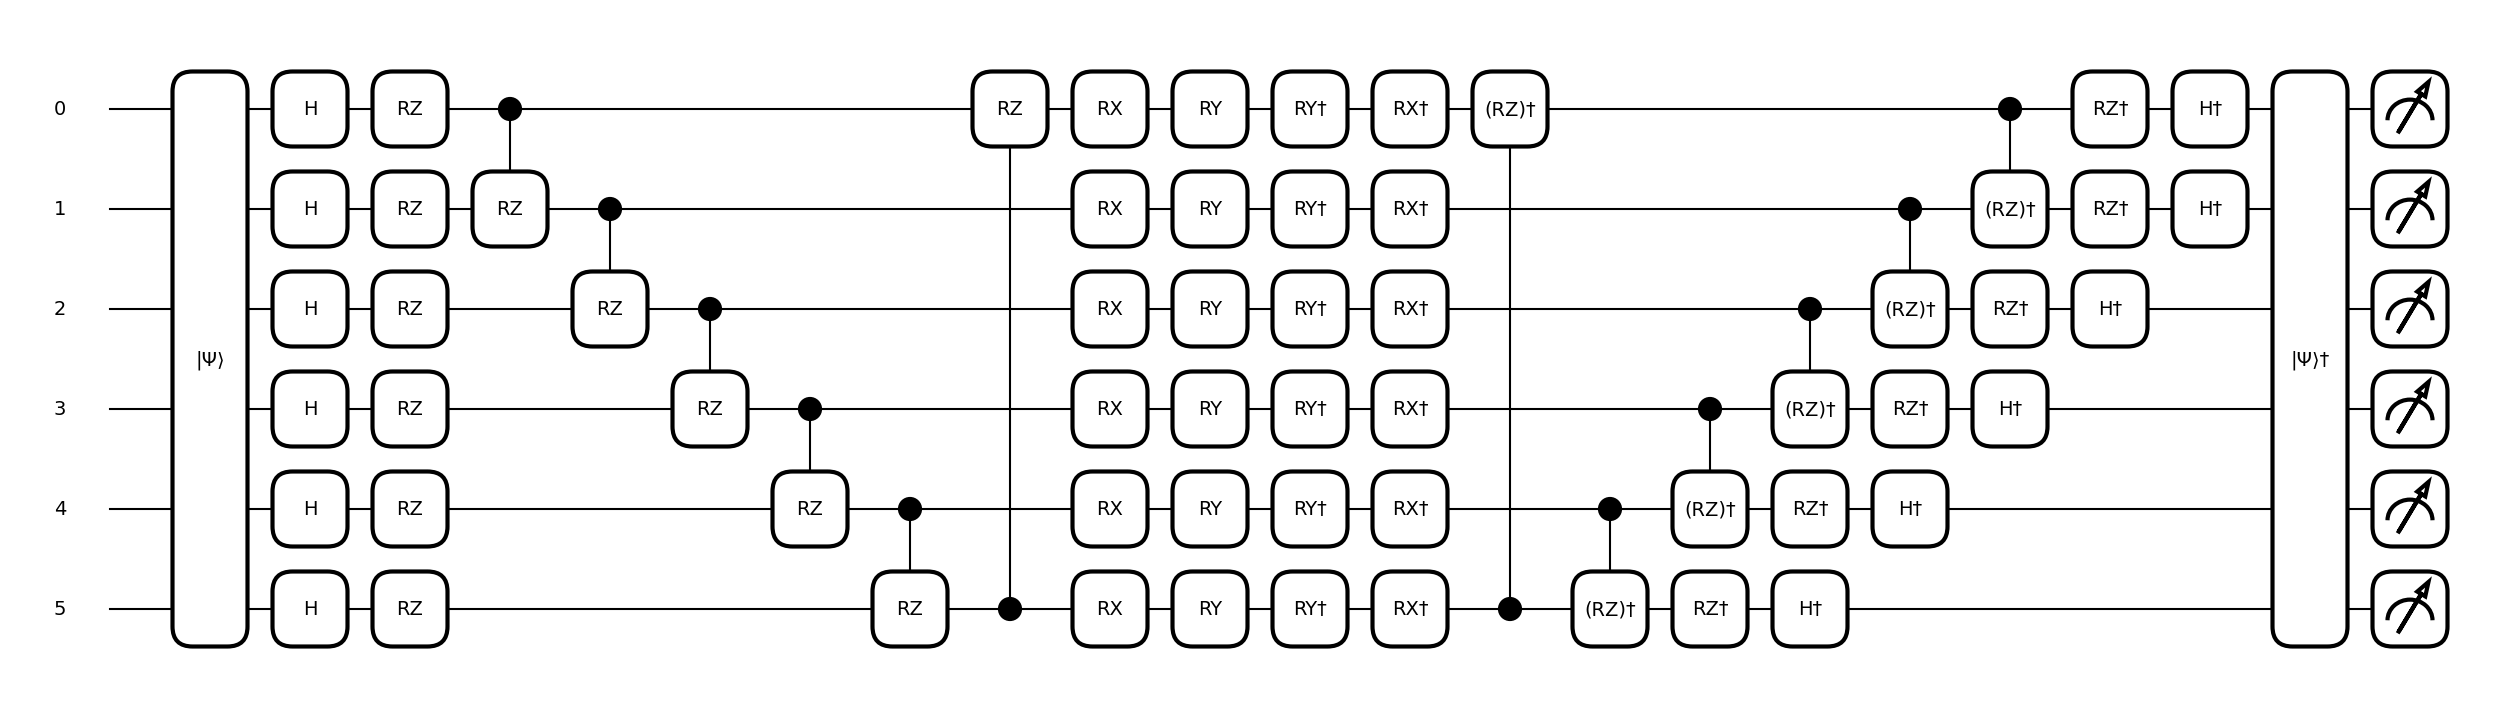

In [16]:
# visualizing the circuit

theta = torch.randn(1, n_qubits, 3, requires_grad=True)
fig, ax = qml.draw_mpl(qek_kernel)(X_train[0], X_train[0], theta, n_qubits)
fig.show()

## Training Theta

In [17]:
batch_size = 64
steps = 150

In [18]:
# --- Ensure all datasets are proper 2D PyTorch tensors ---
import torch
import numpy as pnp

# Convert 8x8 downsampled images
X_train = torch.tensor(pnp.array(X_train), dtype=torch.float32)
X_test  = torch.tensor(pnp.array(X_test), dtype=torch.float32)

# QJPEG features are already tensors, just make sure dtype is float32
X_train_qjpeg = X_train_qjpeg.float()
X_test_qjpeg  = X_test_qjpeg.float()

# Labels should be tensors of type float32
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test  = torch.tensor(y_test, dtype=torch.float32)

In [19]:
theta_1, loss_history_1 = quantum_kernel_train_kta(
    X_train,
    y_train,
    n_qubits=n_qubits,
    n_layers=1,
    steps=steps,
    batch_size=batch_size
)

Step 000 | KTA = 0.0993
Step 005 | KTA = 0.1390
Step 010 | KTA = 0.1129
Step 015 | KTA = 0.1082
Step 020 | KTA = 0.1114
Step 025 | KTA = 0.0836
Step 030 | KTA = 0.0687
Step 035 | KTA = 0.0919
Step 040 | KTA = 0.0884
Step 045 | KTA = 0.1382
Step 050 | KTA = 0.1067
Step 055 | KTA = 0.0875
Step 060 | KTA = 0.1093
Step 065 | KTA = 0.1110
Step 070 | KTA = 0.0877
Step 075 | KTA = 0.1265
Step 080 | KTA = 0.0821
Step 085 | KTA = 0.1189
Step 090 | KTA = 0.0896
Step 095 | KTA = 0.0853
Step 100 | KTA = 0.1082
Step 105 | KTA = 0.0816
Step 110 | KTA = 0.0929
Step 115 | KTA = 0.1154
Step 120 | KTA = 0.1194
Step 125 | KTA = 0.0823
Step 130 | KTA = 0.1229
Step 135 | KTA = 0.0976
Step 140 | KTA = 0.0931
Step 145 | KTA = 0.1007


In [20]:
theta_1_qjpeg, loss_history_1_qjpeg = quantum_kernel_train_kta(
    X_train_qjpeg,
    y_train,
    n_qubits=n_qubits,
    n_layers=1,
    steps=steps,
    batch_size=batch_size
)

Step 000 | KTA = 0.1257
Step 005 | KTA = 0.0988
Step 010 | KTA = 0.1019
Step 015 | KTA = 0.1037
Step 020 | KTA = 0.1310
Step 025 | KTA = 0.1127
Step 030 | KTA = 0.1198
Step 035 | KTA = 0.0910
Step 040 | KTA = 0.1180
Step 045 | KTA = 0.0869
Step 050 | KTA = 0.0871
Step 055 | KTA = 0.0859
Step 060 | KTA = 0.1217
Step 065 | KTA = 0.0942
Step 070 | KTA = 0.0801
Step 075 | KTA = 0.0882
Step 080 | KTA = 0.0788
Step 085 | KTA = 0.1096
Step 090 | KTA = 0.0681
Step 095 | KTA = 0.0771
Step 100 | KTA = 0.0906
Step 105 | KTA = 0.0992
Step 110 | KTA = 0.0915
Step 115 | KTA = 0.1074
Step 120 | KTA = 0.1034
Step 125 | KTA = 0.0991
Step 130 | KTA = 0.1000
Step 135 | KTA = 0.1014
Step 140 | KTA = 0.1187
Step 145 | KTA = 0.1008


In [21]:
theta_2, loss_history_2 = quantum_kernel_train_kta(
    X_train,
    y_train,
    n_qubits=n_qubits,
    n_layers=2,
    steps=steps,
    batch_size=batch_size
)

Step 000 | KTA = 0.0814
Step 005 | KTA = 0.0868
Step 010 | KTA = 0.0784
Step 015 | KTA = 0.0788
Step 020 | KTA = 0.1023
Step 025 | KTA = 0.1023
Step 030 | KTA = 0.0716
Step 035 | KTA = 0.1005
Step 040 | KTA = 0.0989
Step 045 | KTA = 0.1109
Step 050 | KTA = 0.1192
Step 055 | KTA = 0.0955
Step 060 | KTA = 0.1009
Step 065 | KTA = 0.0942
Step 070 | KTA = 0.0953
Step 075 | KTA = 0.0799
Step 080 | KTA = 0.0874
Step 085 | KTA = 0.1216
Step 090 | KTA = 0.1393
Step 095 | KTA = 0.1247
Step 100 | KTA = 0.1066
Step 105 | KTA = 0.0950
Step 110 | KTA = 0.1008
Step 115 | KTA = 0.0895
Step 120 | KTA = 0.1315
Step 125 | KTA = 0.0891
Step 130 | KTA = 0.0785
Step 135 | KTA = 0.1154
Step 140 | KTA = 0.0919
Step 145 | KTA = 0.1044


In [22]:
theta_2_qjpeg, loss_history_2_qjpeg = quantum_kernel_train_kta(
    X_train_qjpeg,
    y_train,
    n_qubits=n_qubits,
    n_layers=2,
    steps=steps,
    batch_size=batch_size
)

Step 000 | KTA = 0.1161
Step 005 | KTA = 0.0834
Step 010 | KTA = 0.1096
Step 015 | KTA = 0.1178
Step 020 | KTA = 0.1083
Step 025 | KTA = 0.0866
Step 030 | KTA = 0.0811
Step 035 | KTA = 0.0816
Step 040 | KTA = 0.0985
Step 045 | KTA = 0.1038
Step 050 | KTA = 0.0928
Step 055 | KTA = 0.1201
Step 060 | KTA = 0.0803
Step 065 | KTA = 0.1357
Step 070 | KTA = 0.1040
Step 075 | KTA = 0.1499
Step 080 | KTA = 0.0889
Step 085 | KTA = 0.0895
Step 090 | KTA = 0.0890
Step 095 | KTA = 0.0855
Step 100 | KTA = 0.1146
Step 105 | KTA = 0.0939
Step 110 | KTA = 0.0884
Step 115 | KTA = 0.1153
Step 120 | KTA = 0.1187
Step 125 | KTA = 0.0795
Step 130 | KTA = 0.1035
Step 135 | KTA = 0.0917
Step 140 | KTA = 0.1140
Step 145 | KTA = 0.1250


In [23]:
theta_4, loss_history_4 = quantum_kernel_train_kta(
    X_train,
    y_train,
    n_qubits = n_qubits,
    n_layers = 4,
    steps = steps,
    batch_size = batch_size
    )

Step 000 | KTA = 0.0940
Step 005 | KTA = 0.1127
Step 010 | KTA = 0.0939
Step 015 | KTA = 0.0983
Step 020 | KTA = 0.0937
Step 025 | KTA = 0.0853
Step 030 | KTA = 0.0842
Step 035 | KTA = 0.1097
Step 040 | KTA = 0.0888
Step 045 | KTA = 0.1272
Step 050 | KTA = 0.1183
Step 055 | KTA = 0.1044
Step 060 | KTA = 0.0894
Step 065 | KTA = 0.0910
Step 070 | KTA = 0.1096
Step 075 | KTA = 0.1262
Step 080 | KTA = 0.0920
Step 085 | KTA = 0.0872
Step 090 | KTA = 0.1037
Step 095 | KTA = 0.0956
Step 100 | KTA = 0.0819
Step 105 | KTA = 0.0955
Step 110 | KTA = 0.1228
Step 115 | KTA = 0.1019
Step 120 | KTA = 0.0863
Step 125 | KTA = 0.0861
Step 130 | KTA = 0.0895
Step 135 | KTA = 0.1067
Step 140 | KTA = 0.1053
Step 145 | KTA = 0.0851


In [24]:
theta_4_qjpeg, loss_history_4_qjpeg = quantum_kernel_train_kta(
    X_train_qjpeg,
    y_train,
    n_qubits = n_qubits,
    n_layers = 4,
    steps = steps,
    batch_size = batch_size
)

Step 000 | KTA = 0.0949
Step 005 | KTA = 0.0871
Step 010 | KTA = 0.1090
Step 015 | KTA = 0.0716
Step 020 | KTA = 0.1115
Step 025 | KTA = 0.1110
Step 030 | KTA = 0.1076
Step 035 | KTA = 0.1758
Step 040 | KTA = 0.1110
Step 045 | KTA = 0.0919
Step 050 | KTA = 0.1161
Step 055 | KTA = 0.1105
Step 060 | KTA = 0.1088
Step 065 | KTA = 0.1320
Step 070 | KTA = 0.1167
Step 075 | KTA = 0.1124
Step 080 | KTA = 0.1219
Step 085 | KTA = 0.1428
Step 090 | KTA = 0.1119
Step 095 | KTA = 0.1206
Step 100 | KTA = 0.1245
Step 105 | KTA = 0.1071
Step 110 | KTA = 0.1197
Step 115 | KTA = 0.1288
Step 120 | KTA = 0.1095
Step 125 | KTA = 0.1035
Step 130 | KTA = 0.1235
Step 135 | KTA = 0.1192
Step 140 | KTA = 0.1024
Step 145 | KTA = 0.1066


In [25]:
# theta_8, loss_history_8 = quantum_kernel_train_kta(
#     X_train,
#     y_train,
#     n_qubits = n_qubits,
#     n_layers = 8,
#     steps = steps,
#     batch_size = batch_size
# )

In [26]:
# theta_8_qjpeg, loss_history_8_qjpeg = quantum_kernel_train_kta(
#     X_train_qjpeg,
#     y_train,
#     n_qubits = n_qubits,
#     n_layers = 8,
#     steps = steps,
#     batch_size = batch_size
# )

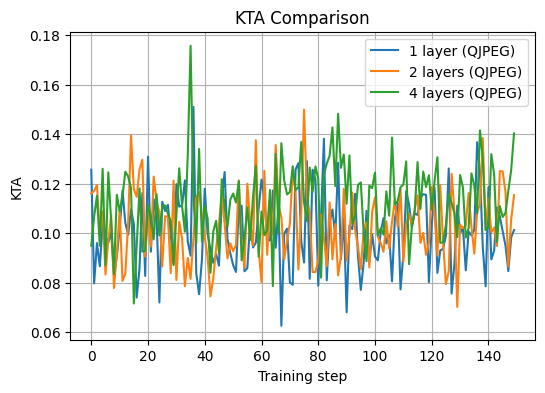

In [27]:
plt.figure(figsize=(6,4))

# plt.plot(loss_history_1, label="1 layer")
plt.plot(loss_history_1_qjpeg, label="1 layer (QJPEG)")
# plt.plot(loss_history_2, label="2 layers")
plt.plot(loss_history_2_qjpeg, label="2 layers (QJPEG)")
# plt.plot(loss_history_4, label="4 layers")
plt.plot(loss_history_4_qjpeg, label="4 layers (QJPEG)")
# plt.plot(loss_history_8, label="8 layers")
# plt.plot(loss_history_8_qjpeg, label="8 layers (QJPEG)")

plt.xlabel("Training step")
plt.ylabel("KTA")
plt.title("KTA Comparison")

plt.legend()
plt.grid(True)

plt.show()

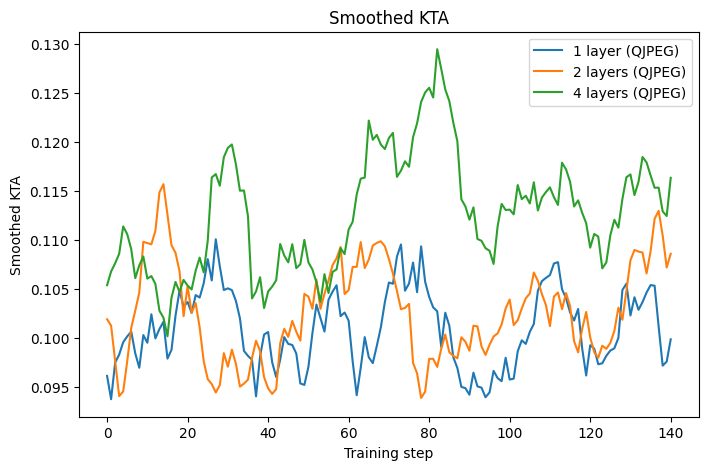

In [28]:
def smooth(x, w=10):
    return np.convolve(x, np.ones(w) / w, mode="valid")

plt.figure(figsize=(8,5))
# plt.plot(smooth(loss_history_1), label="1 layer")
plt.plot(smooth(loss_history_1_qjpeg), label="1 layer (QJPEG)")
# plt.plot(smooth(loss_history_2), label="2 layers")
plt.plot(smooth(loss_history_2_qjpeg), label="2 layers (QJPEG)")
# plt.plot(smooth(loss_history_4), label="4 layers")
plt.plot(smooth(loss_history_4_qjpeg), label="4 layers (QJPEG)")
# plt.plot(smooth(loss_history_8), label="8 layers")
# plt.plot(smooth(loss_history_8_qjpeg), label="8 layers (QJPEG)")

plt.xlabel("Training step")
plt.ylabel("Smoothed KTA")
plt.title("Smoothed KTA")
plt.legend()
plt.grif=True

plt.show()

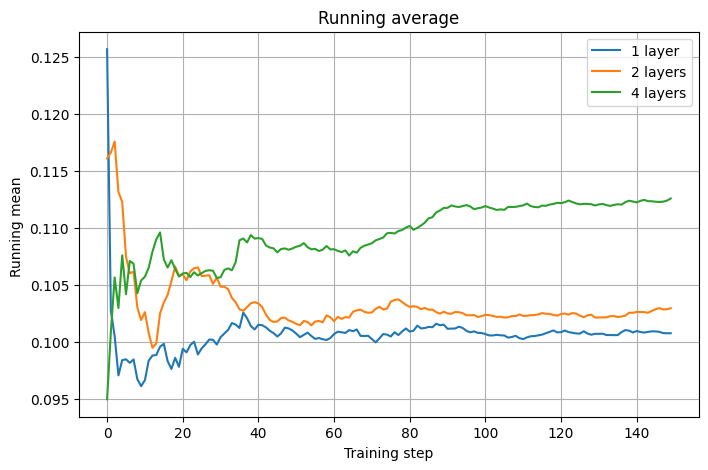

In [29]:
def running_mean(x):
    return np.cumsum(x) / np.arange(1, len(x) + 1)

plt.figure(figsize=(8,5))

# plt.plot(running_mean(loss_history_1), label="1 layer")
plt.plot(running_mean(loss_history_1_qjpeg), label="1 layer")
# plt.plot(running_mean(loss_history_2), label="2 layers")
plt.plot(running_mean(loss_history_2_qjpeg), label="2 layers")
# plt.plot(running_mean(loss_history_4), label="4 layers")
plt.plot(running_mean(loss_history_4_qjpeg), label="4 layers")
# plt.plot(running_mean(loss_history_8), label="8 layers")
# plt.plot(running_mean(loss_history_8_qjpeg), label="8 layers")

plt.xlabel("Training step")
plt.ylabel("Running mean ")
plt.title("Running average")

plt.legend()
plt.grid(True)

plt.show()

## Classification

In [31]:
K_train = msplit_kernel(X_train, theta_1, n_qubits, block_size=12)
K_train_qjpeg = msplit_kernel(X_train_qjpeg, theta_1_qjpeg, n_qubits, block_size=12)

In [32]:
from sklearn.svm import SVC


K_train_np = K_train.detach().numpy()

clf = SVC(kernel='precomputed')
clf.fit(K_train_np, y_train)

# Compute test kernel
K_test_np = np.array([[qek_kernel(x1, x2, theta_1, n_qubits).item()
                       for x2 in X_train] for x1 in X_test])

y_pred = clf.predict(K_test_np)

from sklearn.metrics import accuracy_score
print("Test accuracy:", accuracy_score(y_test, y_pred))

Test accuracy: 0.8166666666666667


In [33]:
K_train_np_qjpeg = K_train_qjpeg.detach().numpy()

clf = SVC(kernel='precomputed')
clf.fit(K_train_np_qjpeg, y_train)

# Compute test kernel
K_test_np_qjpeg = np.array([[qek_kernel(x1, x2, theta_1_qjpeg, n_qubits).item()
                       for x2 in X_train_qjpeg] for x1 in X_test_qjpeg])

y_pred_qjpeg = clf.predict(K_test_np_qjpeg)

from sklearn.metrics import accuracy_score
print("Test accuracy:", accuracy_score(y_test, y_pred_qjpeg))

Test accuracy: 0.8333333333333334


In [34]:
K_train_4 = msplit_kernel(X_train, theta_4, n_qubits, block_size=12)
K_train_qjpeg_4 = msplit_kernel(X_train_qjpeg, theta_4_qjpeg, n_qubits, block_size=12)

In [ ]:
K_train_np_4 = K_train_4.detach().numpy()

clf = SVC(kernel='precomputed')
clf.fit(K_train_np_4, y_train)

# Compute test kernel
K_test_np_4 = np.array([[qek_kernel(x1, x2, theta_4, n_qubits).item()
                       for x2 in X_train] for x1 in X_test])

y_pred_4 = clf.predict(K_test_np_4)

from sklearn.metrics import accuracy_score
print("Test accuracy:", accuracy_score(y_test, y_pred_4))

In [ ]:
K_train_np_4_qjpeg = K_train_qjpeg_4.detach().numpy()

clf = SVC(kernel='precomputed')
clf.fit(K_train_np_4_qjpeg, y_train)

# Compute test kernel
K_test_np_4_qjpeg = np.array([[qek_kernel(x1, x2, theta_4_qjpeg, n_qubits).item()
                       for x2 in X_train_qjpeg] for x1 in X_test_qjpeg])

y_pred_4_qjpeg = clf.predict(K_test_np_4_qjpeg)

from sklearn.metrics import accuracy_score
print("Test accuracy:", accuracy_score(y_test, y_pred_4_qjpeg))